In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("C:\\Users\\DIVISAVEE\\OneDrive\\Desktop\\Savee\\HeartAI\\data\\raw\\heart.csv")

In [5]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [6]:
df.shape

(1025, 14)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [8]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(723)

In [10]:
df = df.drop_duplicates()

In [11]:
df.shape

(302, 14)

In [12]:
df.duplicated().sum()

np.int64(0)

# EDA Observations

1. Dataset contains 1025 records and 14 columns.
2. No missing values found.

In [13]:
df.to_csv(
    "C:\\Users\\DIVISAVEE\\OneDrive\\Desktop\\Savee\\HeartAI\\data\\processed\\heart_cleaned.csv",
    index=False
)

In [14]:
df = pd.read_csv("C:\\Users\\DIVISAVEE\\OneDrive\\Desktop\\Savee\\HeartAI\\data\\processed\\heart_cleaned.csv")

In [15]:
df.shape

(302, 14)

In [16]:
df['target'].value_counts()

target
1    164
0    138
Name: count, dtype: int64

## Target Distribution

- Heart Disease Present (1): 164 patients (54.3%)
- No Heart Disease (0): 138 patients (45.7%)

### Observation

The dataset is relatively balanced and does not exhibit severe class imbalance. Therefore, initial model training can proceed without applying oversampling techniques such as SMOTE.

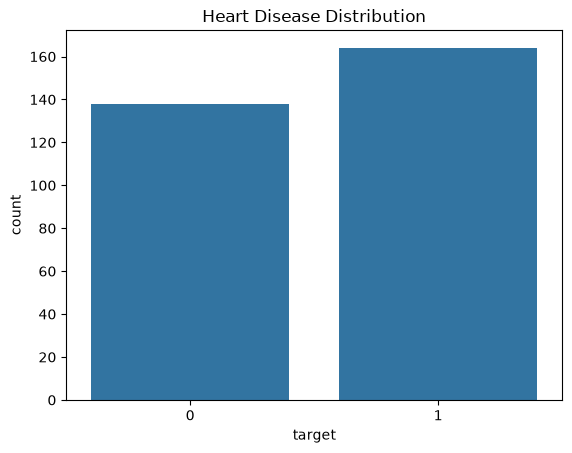

In [17]:
sns.countplot(x='target', data=df)
plt.title("Heart Disease Distribution")
plt.show()

In [18]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,302.00000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000
mean,54.42053,0.682119,0.963576,131.602649,246.500000,0.149007,0.526490,149.569536,0.327815,1.043046,1.397351,0.718543,2.314570,0.543046
std,9.04797,0.466426,1.032044,17.563394,51.753489,0.356686,0.526027,22.903527,0.470196,1.161452,0.616274,1.006748,0.613026,0.498970
min,29.00000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.00000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.250000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.50000,1.000000,1.000000,130.000000,240.500000,0.000000,1.000000,152.500000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.00000,1.000000,2.000000,140.000000,274.750000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.00000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


# Statistical Observations

1. The average age of patients is 54 years.
2. Average resting blood pressure is 132 mmHg.
3. Average cholesterol level is 246 mg/dL, indicating elevated cardiovascular risk.
4. Maximum cholesterol observed is 564 mg/dL, suggesting the presence of outliers.
5. Average maximum heart rate is 150 bpm.
6. The dataset is balanced, with 54.3% positive heart disease cases.

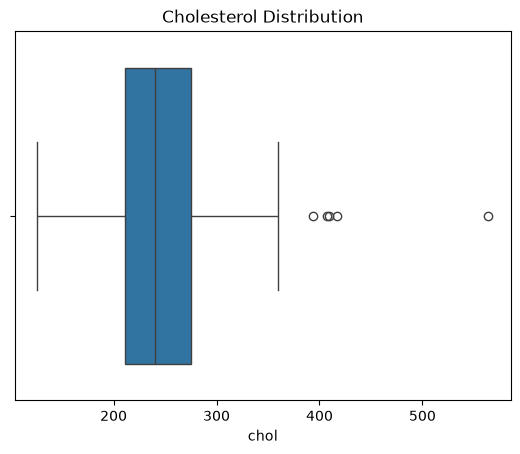

In [19]:
sns.boxplot(x=df['chol'])
plt.title("Cholesterol Distribution")
plt.show()

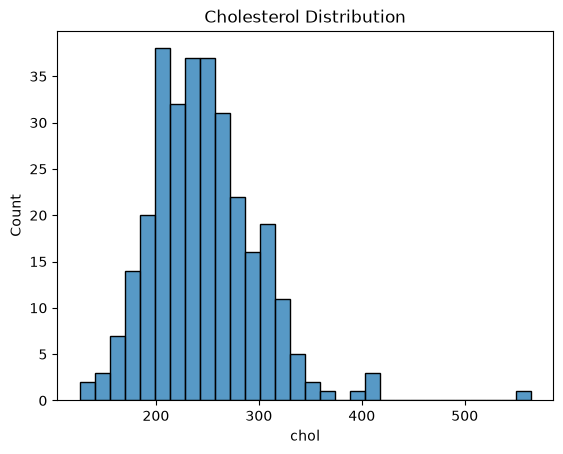

In [20]:
sns.histplot(df['chol'], bins=30)
plt.title("Cholesterol Distribution")
plt.show()

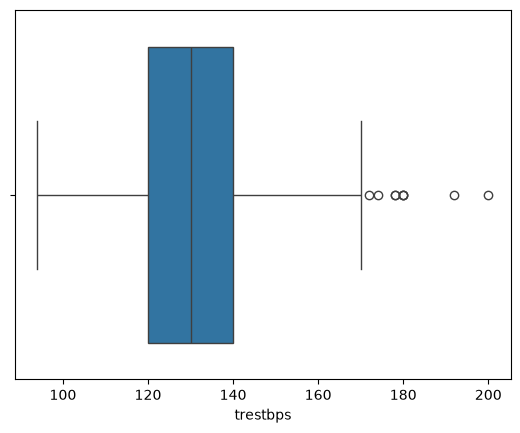

In [21]:
sns.boxplot(x=df['trestbps'])
plt.show()

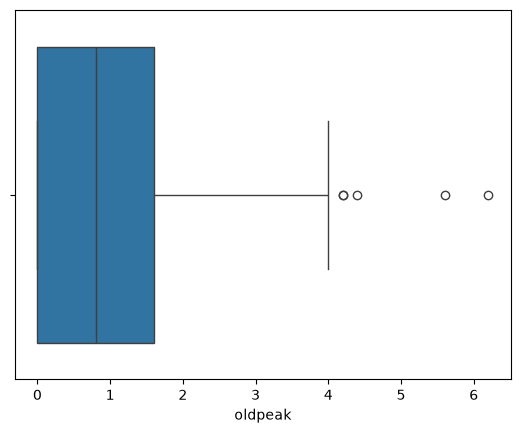

In [22]:
sns.boxplot(x=df['oldpeak'])
plt.show()

# Outlier Analysis

1. Cholesterol contains a few extreme values (>400 mg/dL), but they are medically plausible.
2. Resting blood pressure contains several high values (up to 200 mmHg), indicating hypertensive patients.
3. Oldpeak contains a small number of high values (>4), which may represent severe cardiac abnormalities.
4. Since these outliers are clinically relevant, they were retained for model training.

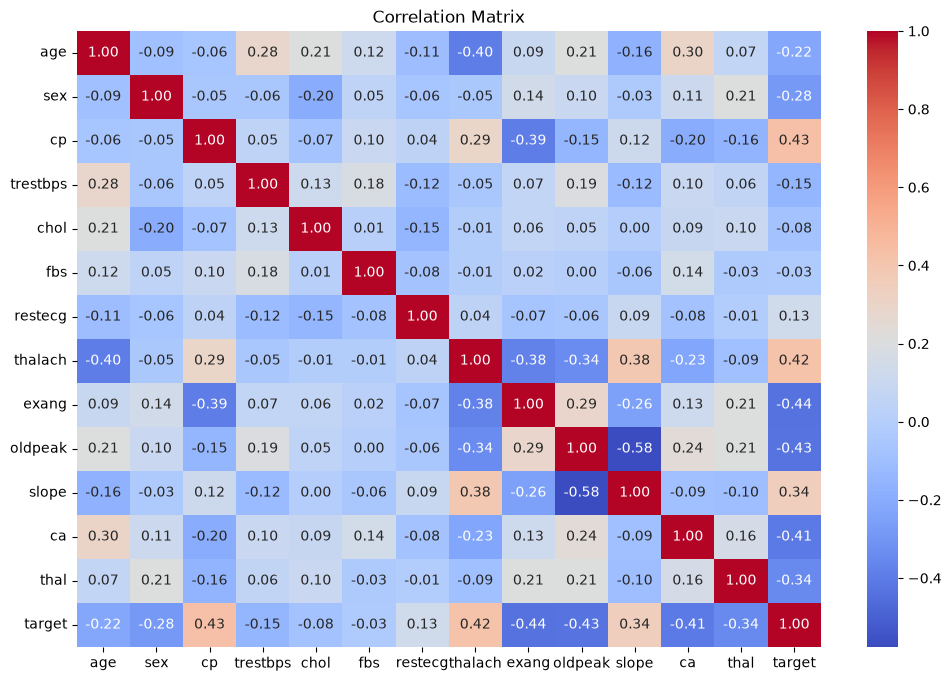

In [23]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

# Correlation Analysis

Top Positive Correlations:

1. Chest Pain (cp): +0.43
2. Maximum Heart Rate (thalach): +0.42
3. Slope: +0.34

Top Negative Correlations:

1. Exercise-Induced Angina (exang): -0.44
2. Oldpeak: -0.43
3. Number of Major Vessels (ca): -0.41
4. Thalassemia (thal): -0.34

## Observations

- Chest pain and maximum heart rate are strong indicators of heart disease.
- Exercise-induced angina and Oldpeak are significant negative predictors.
- Cholesterol and fasting blood sugar exhibit weak correlations with the target variable.